# K-NN Emotion Classification

In [67]:
# library used to save trained models into the .onnx format
!pip install -q skl2onnx onnxruntime

In [68]:
# download dataset FER-2013 from kaggle
import os
!mkdir -p ~/.kaggle
!kaggle datasets download -d msambare/fer2013 -p ./data --unzip

Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:00<00:00, 213MB/s]



In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnx

In [70]:
emotion_map = {
    'angry': 0,
    'disgust': 1,
    'fear': 2,
    'happy': 3,
    'neutral': 4,
    'sad': 5,
    'surprise': 6
}

# feature extraction function
def lbp_features(image, num_points=16, radius=2):

    lbp = local_binary_pattern(image, num_points, radius, method='uniform')
    n_bins = num_points + 2 # histogram bins

    grid_x, grid_y = 6, 6 # divides images into a grid
    h, w = image.shape
    cell_h, cell_w = h // grid_y, w // grid_x # calculates block size

    feats = []
    for i in range(grid_y):
        for j in range(grid_x):
            block = lbp[i * cell_h:(i + 1) * cell_h, j * cell_w:(j + 1) * cell_w]
            hist, _ = np.histogram(block.ravel(), bins=n_bins, range=(0, n_bins))
            feats.append(hist)
    feats = np.concatenate(feats)
    return  feats

# function that loads images into X data and y labels after LBP
def load_images(root):

    X, y = [], []
    for emotion_name, emotion_id in emotion_map.items():

        folder_path = os.path.join(root, emotion_name)
        filenames = os.listdir(folder_path)

        for filename in filenames:
            img_path = os.path.join(folder_path, filename)
            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            features = lbp_features(image)
            X.append(features)
            y.append(emotion_id)

    return np.array(X), np.array(y)

In [71]:
train_dir = './data/train'
test_dir = './data/test'

# gets training and test datasets
X_train, y_train = load_images(train_dir)
X_test, y_test = load_images(test_dir)

print(f"\nTraining set: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Testing set:  {X_test.shape[0]} samples, {X_test.shape[1]} features")


Training set: 28709 samples, 648 features
Testing set:  7178 samples, 648 features


In [75]:
# k-nn algorithm
k_neighbors = 20
knn = KNeighborsClassifier(
    n_neighbors=k_neighbors,
    metric='euclidean',
    weights='distance',
    n_jobs=-1
)

# pipeline that normalizes input before knn
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', knn)
])

# fit and predict
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

Accuracy: 40.85%

Classification Report:
              precision    recall  f1-score   support

       angry      0.299     0.296     0.298       958
     disgust      0.865     0.288     0.432       111
        fear      0.361     0.288     0.320      1024
       happy      0.464     0.608     0.526      1774
     neutral      0.353     0.412     0.380      1233
         sad      0.403     0.196     0.263      1247
    surprise      0.491     0.591     0.536       831

    accuracy                          0.408      7178
   macro avg      0.462     0.383     0.394      7178
weighted avg      0.407     0.408     0.395      7178



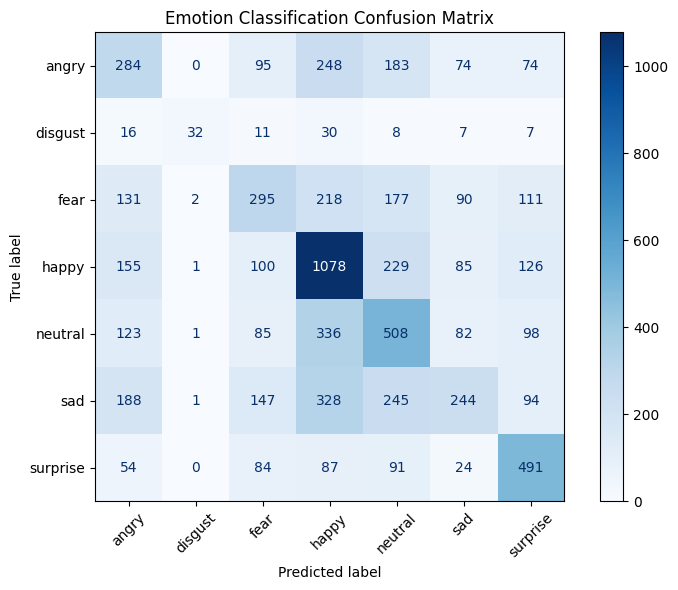

In [76]:

# calculate accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%\n")

# target class labels in order
target_names = list(emotion_map.keys())

# classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, digits=3))

# plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=target_names,
    cmap='Blues',
    ax=ax,
    xticks_rotation=45
)
plt.title('Emotion Classification Confusion Matrix')
plt.tight_layout()
plt.show()

In [77]:

# define input signature
initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]

onnx_model = convert_sklearn(
    pipe,
    initial_types=initial_type,
    options={id(knn): {"zipmap": False}},
    target_opset={"": 13, "ai.onnx.ml": 3},
)

# save the model
output_path = "lbp_knn.onnx"
onnx.save_model(onnx_model, output_path)
print(f"Successfully converted and saved to {output_path}")

Successfully converted and saved to lbp_knn.onnx
